In [1]:
from contextlib import contextmanager
from pathlib import Path

import matplotlib
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.integrate import solve_ivp
from scipy.interpolate import PchipInterpolator
from tqdm import tqdm

DATA_DIR = Path("data")
FIG_DIR = Path("fig")

In [2]:
from genesis_background import (
    background, z_squared, z_of_x, cR_squared, zddz, omega2 as Omega2,
)

In [3]:
def choose_x_ini(kappa, d, alpha0, safety=1e5,
                 x_min=1e-2, x_max=1e19, n=800, multiplier=2.0):
    xs   = np.geomspace(x_min, x_max, n)
    mass = zddz(xs, d, alpha0, kappa)
    cR2 = cR_squared(xs, d, alpha0, kappa)
    omg2 = cR2 * kappa**2 - mass
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(np.abs(mass) > 0,
                         np.abs(cR2 * kappa**2 / mass), np.inf)
    ok = (np.isfinite(ratio) & np.isfinite(omg2)
          & (ratio >= safety) & (cR2 > 0) & (omg2 > 0))
    x_pick = float(xs[np.where(ok)[0][0]]) if ok.any() else x_max
    return min(x_pick * multiplier, x_max)

In [4]:
def solve_mode(kappa, d, alpha0, x_final=1e-6, x_ini=None,
               n_background=2000, rtol=1e-6, atol=1e-8):
    if x_ini is None:
        x_ini = choose_x_ini(kappa, d, alpha0)
    xg   = np.geomspace(x_final, x_ini, n_background)
    zg   = z_of_x(xg, d, alpha0, kappa)
    cR2g = cR_squared(xg, d, alpha0, kappa)
    mg   = zddz(xg, d, alpha0, kappa)
    zI   = PchipInterpolator(xg, zg,   extrapolate=False)
    cI   = PchipInterpolator(xg, cR2g, extrapolate=False)
    mI   = PchipInterpolator(xg, mg,   extrapolate=False)

    om_ini = np.sqrt(abs(float(cR2g[-1] * kappa**2 - mg[-1])))
    h = max(1e-8, 1e-5 * x_ini)
    def omloc(xx):
        v = float(cR_squared(xx,d,alpha0,kappa)*kappa**2 - zddz(xx,d,alpha0,kappa))
        return np.sqrt(max(v, 0.0))
    om_p = (omloc(x_ini-2*h) - 8*omloc(x_ini-h)
            + 8*omloc(x_ini+h) - omloc(x_ini+2*h)) / (12*h)
    u_ini  = 1.0 / np.sqrt(2.0 * om_ini)
    up_ini = (1j*om_ini - 0.5*om_p/om_ini) * u_ini

    def rhs(x, y):
        om2 = float(cI(x))*kappa**2 - float(mI(x))
        return [y[2], y[3], -om2*y[0], -om2*y[1]]

    max_step = min(0.20 / max(om_ini, kappa, 1e-12), (x_ini - x_final) / 2000)
    y0 = [u_ini.real, u_ini.imag, up_ini.real, up_ini.imag]

    for method in ('DOP853', 'Radau'):
        sol = solve_ivp(rhs, (x_ini, x_final), y0, method=method,
                        rtol=rtol, atol=atol, dense_output=True, max_step=max_step)
        if sol.success:
            break
    return sol, zI, x_ini

wrote fig\vcdm_R_single_model.png


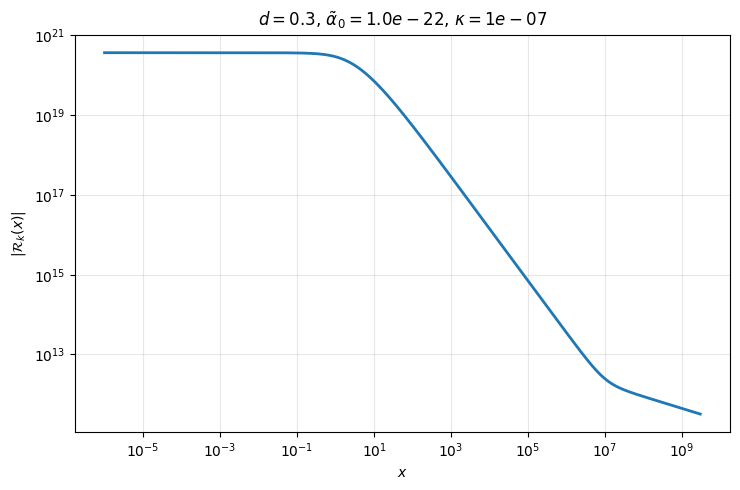

In [5]:
d = 0.3
alpha0 = 1e-22
kappa = 1e-7
x_final = 1e-6

sol, zI, x_ini = solve_mode(kappa, d, alpha0, x_final=x_final)

x_array = np.geomspace(x_final, x_ini, 1500)
y = sol.sol(x_array)
u_array = y[0] + 1j*y[1]
R_array = np.abs(u_array / zI(x_array))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(x_array, R_array, lw=2)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$|\mathcal{R}_k(x)|$')
ax.set_title(rf'$d={d}$, $\tilde{{\alpha}}_0={alpha0:.1e}$, $\kappa={kappa:.0e}$')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
f = FIG_DIR / "vcdm_R_single_model.png"
fig.savefig(f, bbox_inches="tight")
print(f"wrote {f}")
if matplotlib.get_backend().lower() == "agg":
    plt.close(fig)
else:
    plt.show()


In [6]:
try:
    import joblib
    from joblib import Parallel, delayed
except ImportError:
    joblib = Parallel = delayed = None

N = 2**12
seed = 123
n_jobs = -1
x_final = 1e-6
n_eval = 1500
out_file = DATA_DIR / "vcdm_R_scan.npz"

priors = {
    "d": (0.1, 0.4),
    "log10_alpha0": (-30.0, -21.0),
    "log10_kappa": (-9.0, -4.0),
}

@contextmanager
def tqdm_joblib(bar):
    if joblib is None:
        yield bar
        bar.close()
        return

    old_callback = joblib.parallel.BatchCompletionCallBack

    class Callback(old_callback):
        def __call__(self, *args, **kwargs):
            bar.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    joblib.parallel.BatchCompletionCallBack = Callback
    try:
        yield bar
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        bar.close()

def make_points():
    rng = np.random.default_rng(seed)

    d = rng.uniform(*priors["d"], N)
    alpha0 = 10.0 ** rng.uniform(*priors["log10_alpha0"], N)
    kappa = 10.0 ** rng.uniform(*priors["log10_kappa"], N)

    params = np.column_stack([d, alpha0, kappa])

    return params

def compute_R_function(params):
    d, alpha0, kappa = map(float, params)

    try:
        x_ini = choose_x_ini(kappa, d, alpha0, safety=1e5, n=600)

        cr2_ini = float(cR_squared(x_ini, d, alpha0, kappa))
        om2_ini = float(Omega2(x_ini, d, alpha0, kappa))

        if not (
            np.isfinite(cr2_ini)
            and np.isfinite(om2_ini)
            and cr2_ini > 0.0
            and om2_ini > 0.0
        ):
            return None

        sol, zI, x_ini = solve_mode(
            kappa, d, alpha0,
            x_final=x_final,
            x_ini=x_ini,
            n_background=800,
            rtol=3e-5,
            atol=1e-7,
        )

        if not sol.success:
            return None

        x = np.geomspace(x_final, x_ini, n_eval)
        y = sol.sol(x)

        u = y[0] + 1j * y[1]
        R_abs = np.abs(u / zI(x))

        return d, alpha0, kappa, x, R_abs

    except Exception:
        return None

params = make_points()

if Parallel is None or n_jobs == 1:
    results = [
        compute_R_function(p)
        for p in tqdm(params, desc="scan", unit="model")
    ]
else:
    with tqdm_joblib(tqdm(total=len(params), desc="scan", unit="model")):
        results = Parallel(n_jobs=n_jobs)(
            delayed(compute_R_function)(p) for p in params
        )

results = [r for r in results if r is not None]


out_file.parent.mkdir(exist_ok=True)

np.savez_compressed(
    out_file,
    d=np.array([r[0] for r in results]),
    alpha0=np.array([r[1] for r in results]),
    kappa=np.array([r[2] for r in results]),
    x=np.vstack([r[3] for r in results]),
    R_abs=np.vstack([r[4] for r in results]),
)

print(f"Saved to {out_file.resolve()}")

scan: 100%|██████████| 4096/4096 [03:14<00:00, 21.01model/s]


Saved to C:\Users\pavel\Documents\GitHub\VCDM_full_spectrum_fit\data\vcdm_R_scan.npz


,model_id,d,alpha0,kappa
0,63,0.231232,5.892874e-28,0.000015
1,2794,0.308033,1.125081e-24,0.000012


wrote fig\vcdm_R_random_models.png


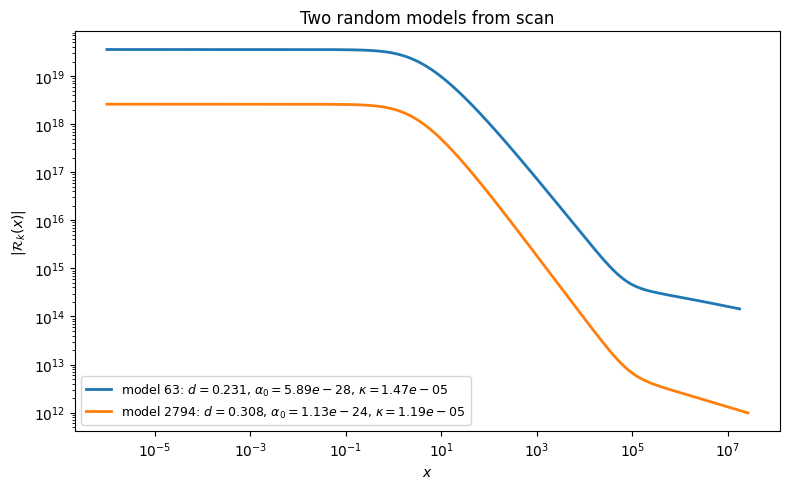

In [7]:
file = DATA_DIR / "vcdm_R_scan.npz"

data = np.load(file)

d = data["d"]
alpha0 = data["alpha0"]
kappa = data["kappa"]
x = data["x"]
R_abs = data["R_abs"]

n_models = len(d)

seed = 123
rng = np.random.default_rng(seed)
ids = rng.choice(n_models, size=2, replace=False)

params = pd.DataFrame({
    "model_id": ids,
    "d": d[ids],
    "alpha0": alpha0[ids],
    "kappa": kappa[ids],
})

display(params)

fig, ax = plt.subplots(figsize=(8, 5))

for i in ids:
    ax.loglog(
        x[i],
        R_abs[i],
        lw=2,
        label=(
            rf"model {i}: "
            rf"$d={d[i]:.3g}$, "
            rf"$\alpha_0={alpha0[i]:.2e}$, "
            rf"$\kappa={kappa[i]:.2e}$"
        ),
    )

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$|\mathcal{R}_k(x)|$")
ax.set_title(r"Two random models from scan")
ax.legend(fontsize=9)
fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
f = FIG_DIR / "vcdm_R_random_models.png"
fig.savefig(f, bbox_inches="tight")
print(f"wrote {f}")

